# 📄 SOTA Universal NLP Engine — Syntax Guide & Protocol

This notebook orchestrates the `AutoMLFactory` for **text intelligence** workloads. The engine supports **three distinct NLP modes**, automatically routed by the `AUTOML_CONFIG` dictionary.

> **Important**: Your raw text can be dirty — the engine applies a **production-grade 15-step Text Cleanliness Guard** that handles HTML, URLs, emojis, Indonesian slang, English slang, repeated characters, and more. The CSV must simply be structurally valid with a well-defined text column. **No language specification is needed** — language is auto-detected.

---

## 🧠 Task Mode Routing Logic

The engine determines the NLP mode automatically based on configuration keys:

| Priority | Condition | Routed Mode | Backend |
|:---|:---|:---|:---|
| 1 | `target_column` is set (non-empty) | **Supervised** | AutoGluon Tabular + BGE-M3 Embeddings |
| 2 | `candidate_labels` is set (list of strings) | **Zero-Shot** | HuggingFace `mDeBERTa-v3-base-mnli-xnli` |
| 3 | Neither target nor labels provided | **Unsupervised** | BERTopic + BGE-M3 Embeddings |

---

## 📜 The Configuration Schema

The `AUTOML_CONFIG` dictionary defines the engine's behavior. Below are the keys strictly related to `task_type = "nlp"`.

| Key | Type | Description | Available Options | Example |
|:---|:---|:---|:---|:---|
| `experiment_name` | `str` | MLflow experiment identifier. | Any string | `"Sentiment_Analysis"` |
| `task_type` | `str` | ML task routing. Must be `"nlp"`. | `"nlp"` | `"nlp"` |
| `dataset_path` | `str` | Path to dataset CSV with text features. | Any valid path | `"Dataset/reviews.csv"` |
| `text_column` | `str` | **(Required)** Column containing raw text. | Column name in dataset | `"review_body"` |
| `target_column` | `str` | Label column for **Supervised** mode. Omit or set `""` for Zero-Shot/Unsupervised. | Column name, `""` | `"sentiment"` |
| `candidate_labels` | `List[str]` | Candidate labels for **Zero-Shot** classification. Only used when `target_column` is empty. | List of label strings, `None` | `["positive", "negative", "neutral"]` |
| `base_output_dir` | `str` | Centralized artifact output root directory. | Any valid directory path | `"automl_nlp_run"` |
| `prediction_data_path` | `str` | Path to unseen data for batch inference. | Any valid path, `None` | `"Dataset/unseen_reviews.csv"` |
| `presets` | `str` | Supervised training preset (maps to AutoGluon Tabular + BGE-M3 Embeddings). | `"extreme"`, `"best"`, `"high"`, `"medium"` | `"medium"` |
| `calibrate_decision_threshold` | `bool` | Calibrate decision threshold (binary classification only). | `True`, `False` | `False` |
| `auto_stack` | `bool` | Auto-stack ensemble models for boosted performance. | `True`, `False` | `False` |
| `time_limit_seconds` | `int` | Maximum training time limit allowed in seconds. | Any positive integer | `300` |
| `nlp_embedding_batch_size` | `int` | Batch size for BGE-M3 embedding extraction (Unsupervised). | Any positive integer | `16` |
| `nlp_zero_shot_batch_size` | `int` | Batch size for Zero-Shot inference pipeline. | Any positive integer | `8` |
| `fast_dev_run` | `bool` | Quick prototyping mode (subsamples data). | `True`, `False` | `False` |
| `ai_context` | `str` | Business context string to guide the AI natural language report summary. | Any string, `None` | `"Classifying customer support tickets and modeling themes from user feedback."` |

### 🚫 Strict Rules
1. **Text Column Required**: `text_column` must always be specified and must exist in the dataset.
2. **Mutual Exclusivity**: `target_column` and `candidate_labels` should not both be set. If `target_column` is present, it takes priority (Supervised mode).
3. **Unseen Schema Match**: Prediction data passed to `prediction_data_path` must contain the same `text_column` as the training data.
4. **Embedding Model**: Unsupervised mode uses `BAAI/bge-m3` (1024-dim) embeddings. The model is cached in `{base_output_dir}/models_nlp/bge_m3_cache/`.
5. **GPU Awareness**: All three modes auto-detect CUDA availability and route inference to GPU when available.

### 📋 Blank Configuration Template

Copy this block and customize for your dataset:

```python
AUTOML_CONFIG = {
    # ── Core Pipeline Settings ──────────────────────────────────────
    "experiment_name": "NLP_Experiment",
    "task_type": "nlp",
    "dataset_path": "Dataset/your_file.csv",
    "text_column": "your_text_column",      # Column with raw text
    "target_column": ["your_target"],      # List[str] — leave empty [] for Unsupervised Topics
    "candidate_labels": None,              # List[str] — candidate labels for Zero-Shot mode

    # ── Model Training & Metrics ────────────────────────────────────
    "presets": "medium",
    "time_limit_seconds": 600,
    "calibrate_decision_threshold": False,  # Calibrate threshold (supervised binary classification only)
    "auto_stack": False,                    # Enable ensemble stacking for supervised models
    "nlp_embedding_batch_size": 16,         # Batch size for embedding extraction
    "nlp_zero_shot_batch_size": 8,          # Batch size for zero-shot inference pipeline

    # ── Infrastructure & Inference ──────────────────────────────────
    "base_output_dir": "automl_run",
    "prediction_data_path": None,
    "fast_dev_run": False,                  # Set False for production runs

    # ── AI Audit Narrative ──────────────────────────────────────────
    "ai_context": "Classifying customer support tickets and modeling themes from user feedback."
}
```


---
## ⚙️ Step 1: Pipeline Configuration
Customize the dictionary below for your dataset and experiment. The routing mode is determined automatically based on the presence of `target_column` and `candidate_labels`.

In [1]:
# ══════════════════════════════════════════════════════════════════════
#  Pipeline Configuration
# ══════════════════════════════════════════════════════════════════════

AUTOML_CONFIG = {
    # ── Core Pipeline Settings ──────────────────────────────────────
    "experiment_name": "NLP_TopicModeling_Run",
    "task_type": "nlp",
    "dataset_path": "dummy_dataset/nlp_unsupervised.csv",
    "text_column": "doc_text",              # Column containing raw text
    "target_column": [],                    # Empty [] triggers Unsupervised mode
    "candidate_labels": [],                 # Empty/None for unsupervised topic modeling

    # ── Model Training & Metrics ────────────────────────────────────
    "presets": "medium",
    "time_limit_seconds": 120,
    "calibrate_decision_threshold": False,  # Calibrate threshold (supervised binary classification only)
    "auto_stack": False,                    # Enable ensemble stacking for supervised models
    "nlp_embedding_batch_size": 32,         # Batch size for embedding extraction
    "nlp_zero_shot_batch_size": 8,          # Batch size for zero-shot inference pipeline

    # ── Infrastructure & Inference ──────────────────────────────────
    "base_output_dir": "automl_nlp_run",
    "prediction_data_path": None,
    "fast_dev_run": False,

    # ── AI Audit Narrative ──────────────────────────────────────────
    "ai_context": "Classifying customer support tickets and modeling themes from user feedback."
}


---
## 🚀 Step 2: Execute Engine
This orchestrates text cleaning (15-step guard), language detection, embedding extraction, model training (or zero-shot inference), evaluation, plot generation, MLflow logging, and the premium HTML dashboard — all automatically based on the routing mode.

Topic,Count,Name,Representation,Gemini Label,Representative Docs
-1,1,Outliers,"['paling', 'lanjutjs', 'reactjs', 'kalangan', 'frontend', 'framework', 'populer', 'developer', 'jadi', 'indonesia']","['paling', 'lanjutjs', 'reactjs', 'kalangan', 'frontend', 'framework', 'populer', 'developer', 'jadi', 'indonesia']",['react.js dan lanjut.js masih jadi framework frontend paling populer di kalangan developer indonesia']
0,20,Advanced Artificial Intelligence Models,"['learning', 'models', 'data', 'improved', 'complex', 'ai', 'applications', 'algorithms', 'latest', 'like']","['Advanced Artificial Intelligence Models', 'learning', 'models', 'data', 'improved', 'complex', 'ai', 'applications', 'algorithms', 'latest']","['the integration of ai in healthcare enables early disease detection through medical imaging analysis', 'natural language processing models like bert and gpt have transformed how machines understand human language', 'the james webb space telescope captured new images of distant galaxies forming in the early universe']"
1,19,Proyeksi Pertumbuhan Ekonomi Indonesia,"['indonesia', '2026', 'baru', 'didorong', 'global', 'pemerintah', 'naik', 'terus', 'tinggi', 'including']","['Proyeksi Pertumbuhan Ekonomi Indonesia', 'indonesia', '2026', 'baru', 'didorong', 'global', 'pemerintah', 'naik', 'terus', 'tinggi']","['climate change is causing more frequent extreme weather events including floods and droughts worldwide', 'timnas indonesia berhasil lolos ke babak semifinal piala aff 2026 setelah mengalahkan thailand', 'renewable energy sources including solar and wind now account for 30% of global electricity generation']"
2,11,Panduan Resep Kuliner Tradisional,"['cara', 'tips', 'cendol', 'gula', 'es', 'santan', 'resep', 'kopi', 'nasi', 'kecil']","['Panduan Resep Kuliner Tradisional', 'cara', 'tips', 'cendol', 'gula', 'es', 'santan', 'resep', 'kopi', 'nasi']","['tips diet sehat: kurangi gula, perbanyak sayur dan buah, olahraga rutin minimal 30 menit/hari', 'resep es cendol: campurkan cendol, santan, gula merah cair, dan es batu. seger banget!', 'cara merawat tanaman hias: siram 2x sehari, kasih pupuk tiap 2 minggu, taruh di tempat teduh']"

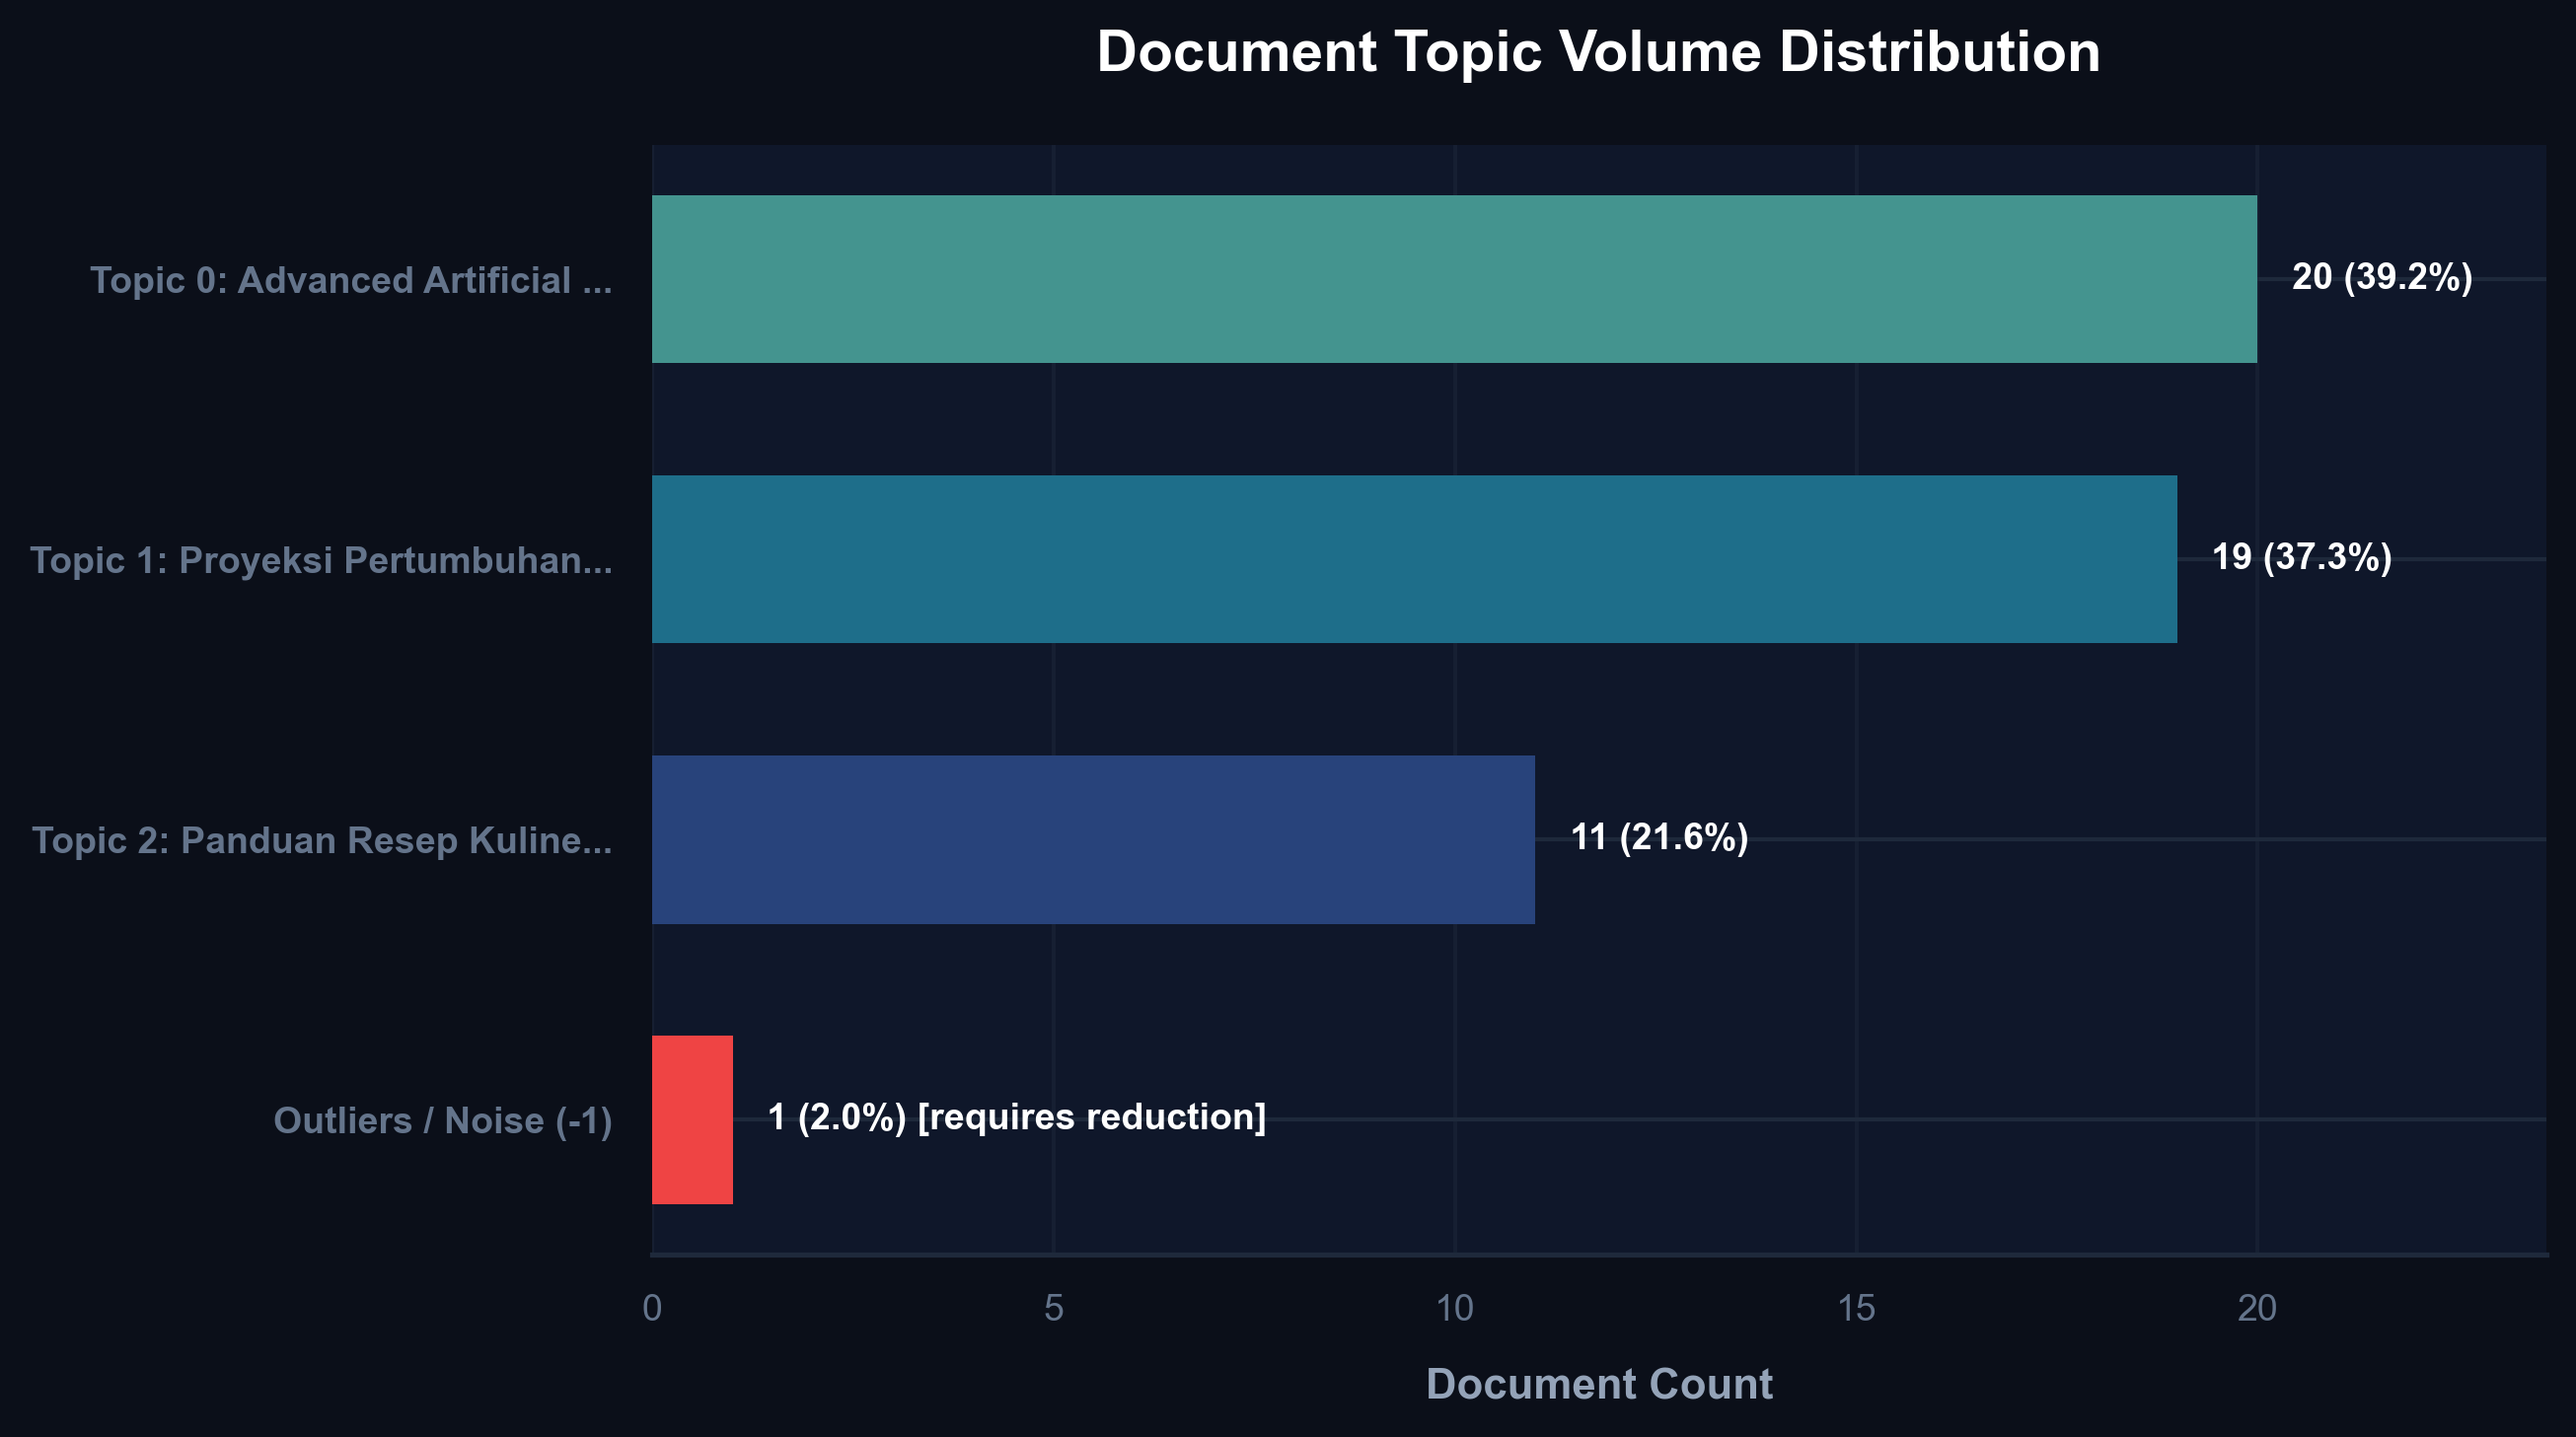
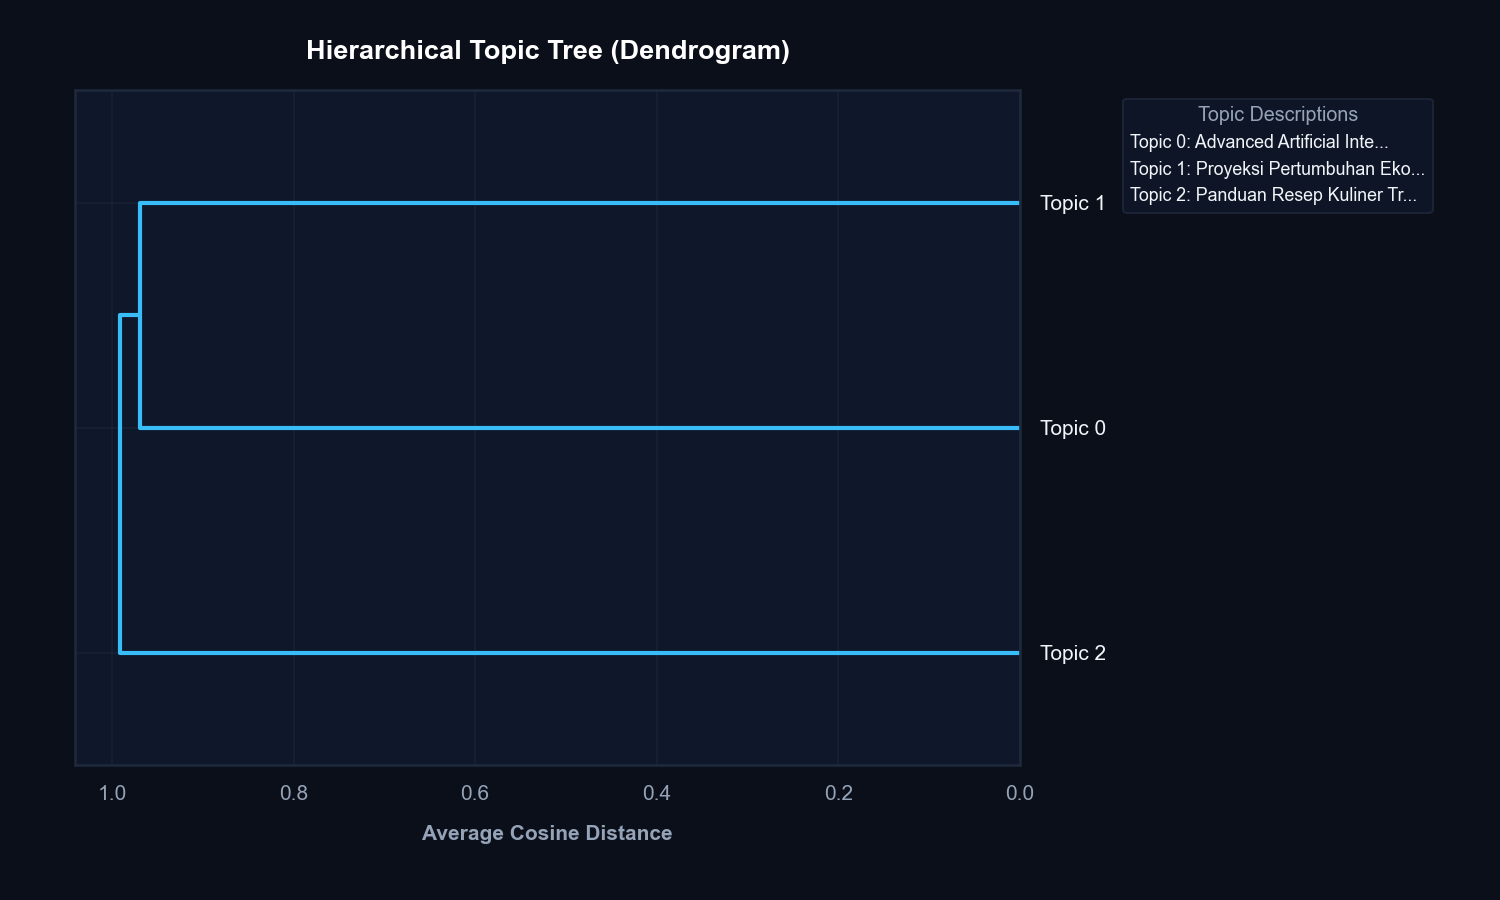
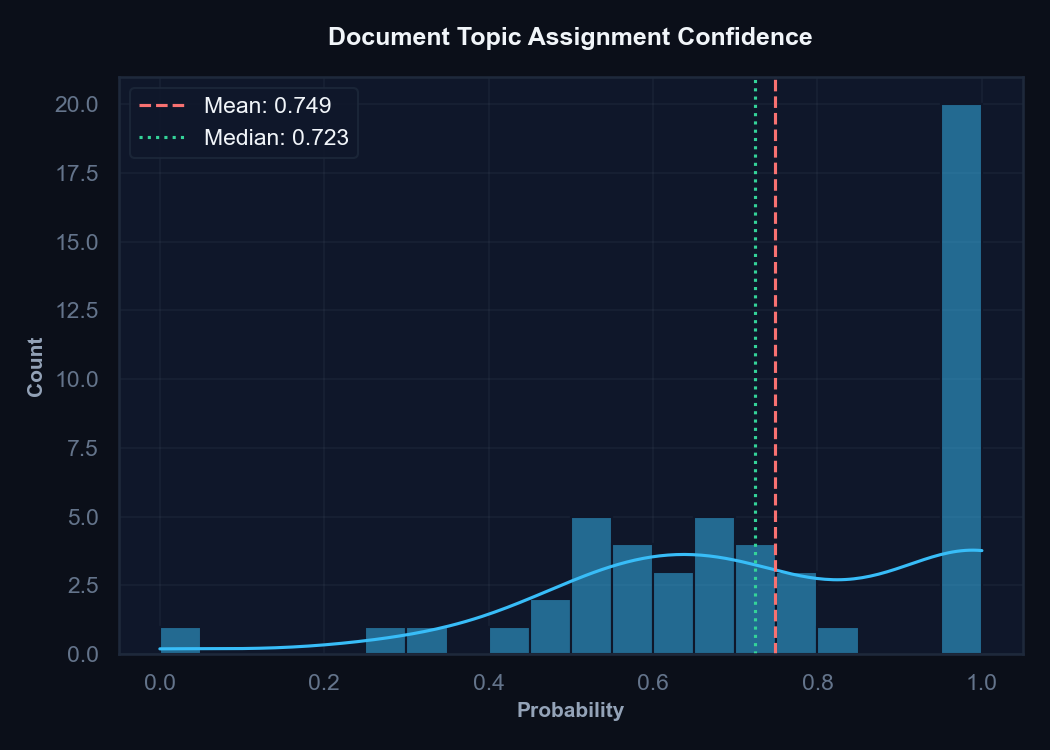
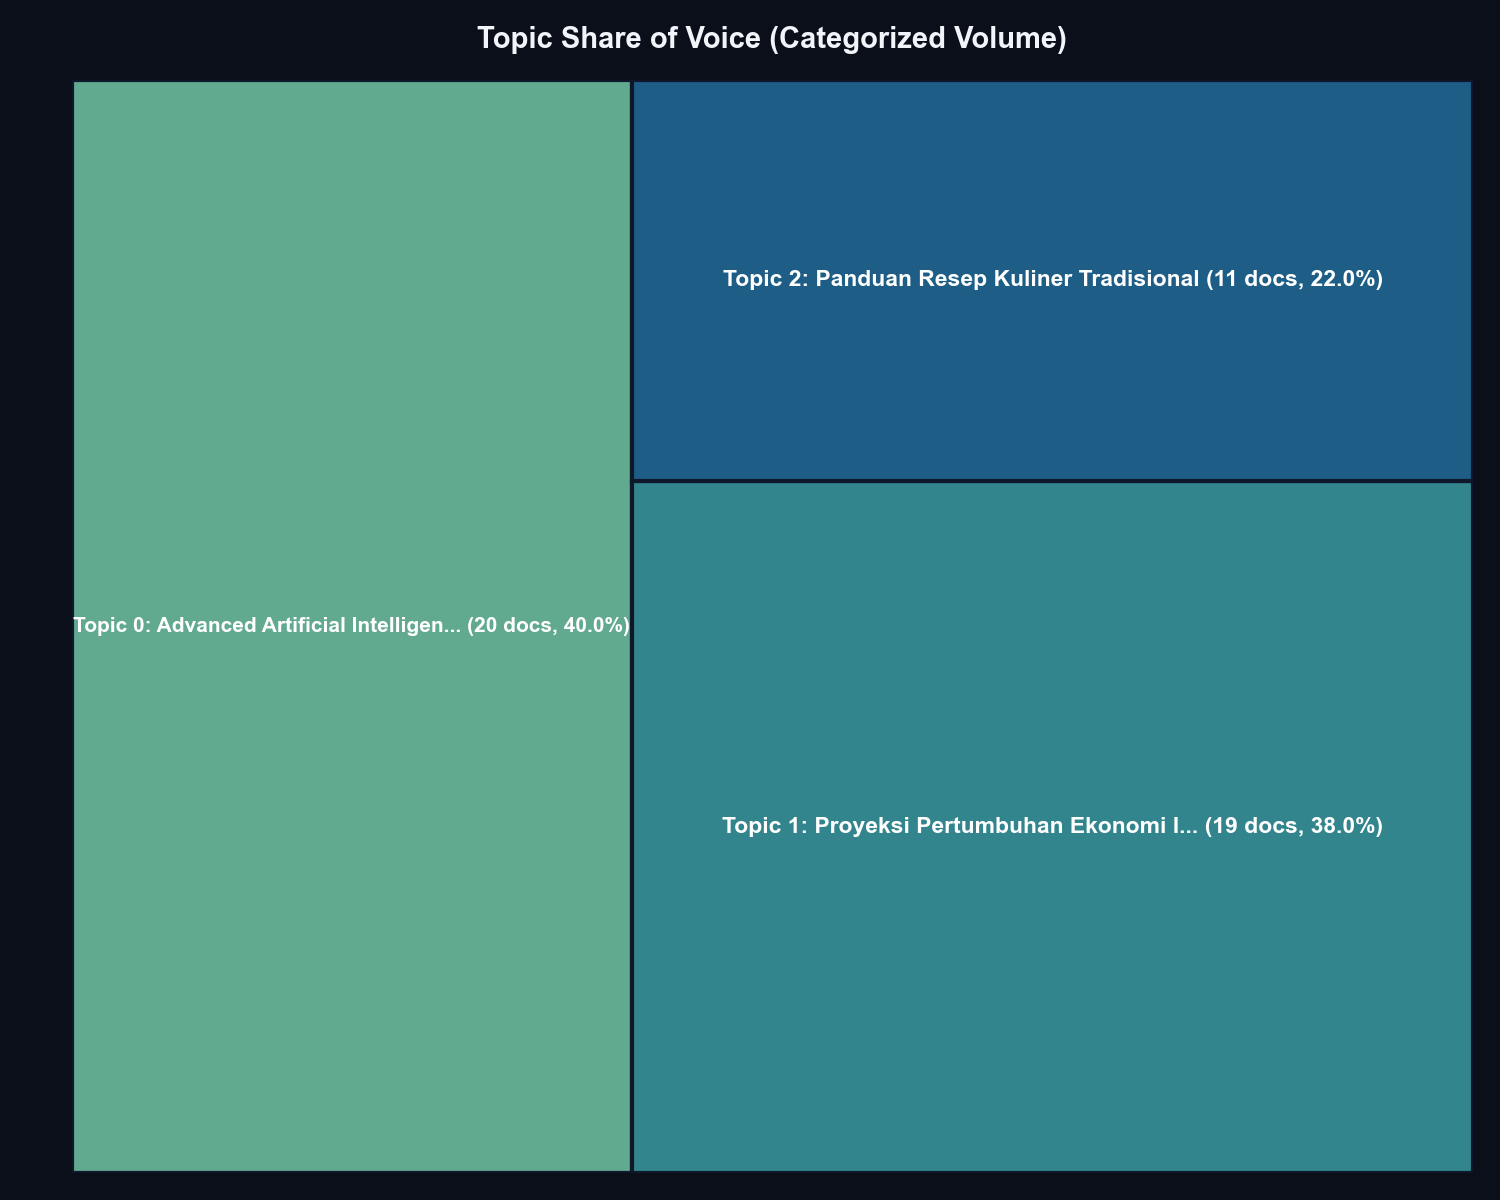
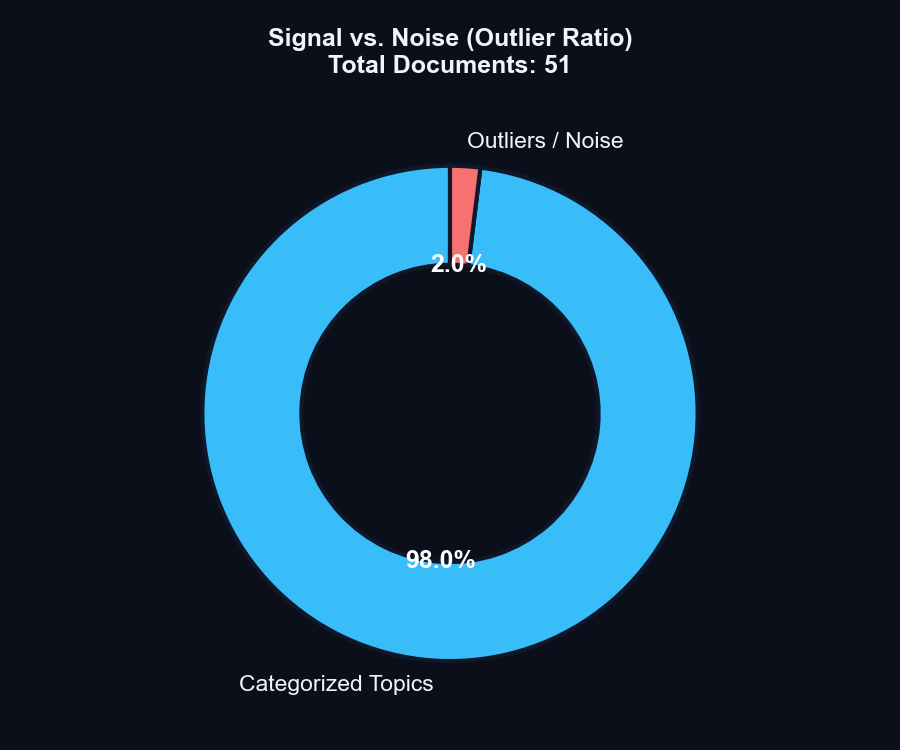
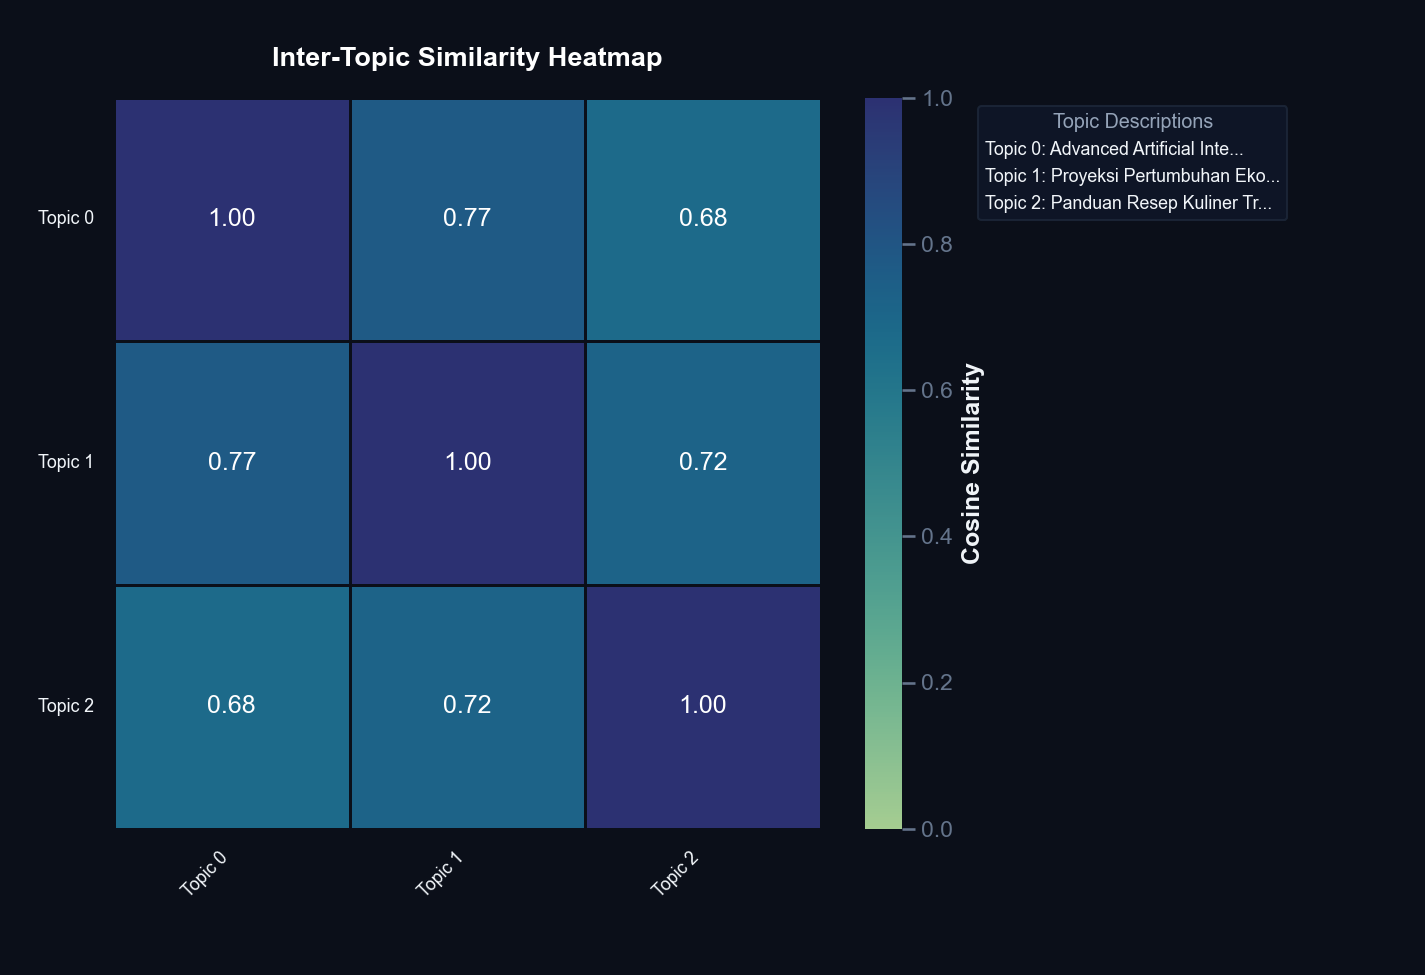
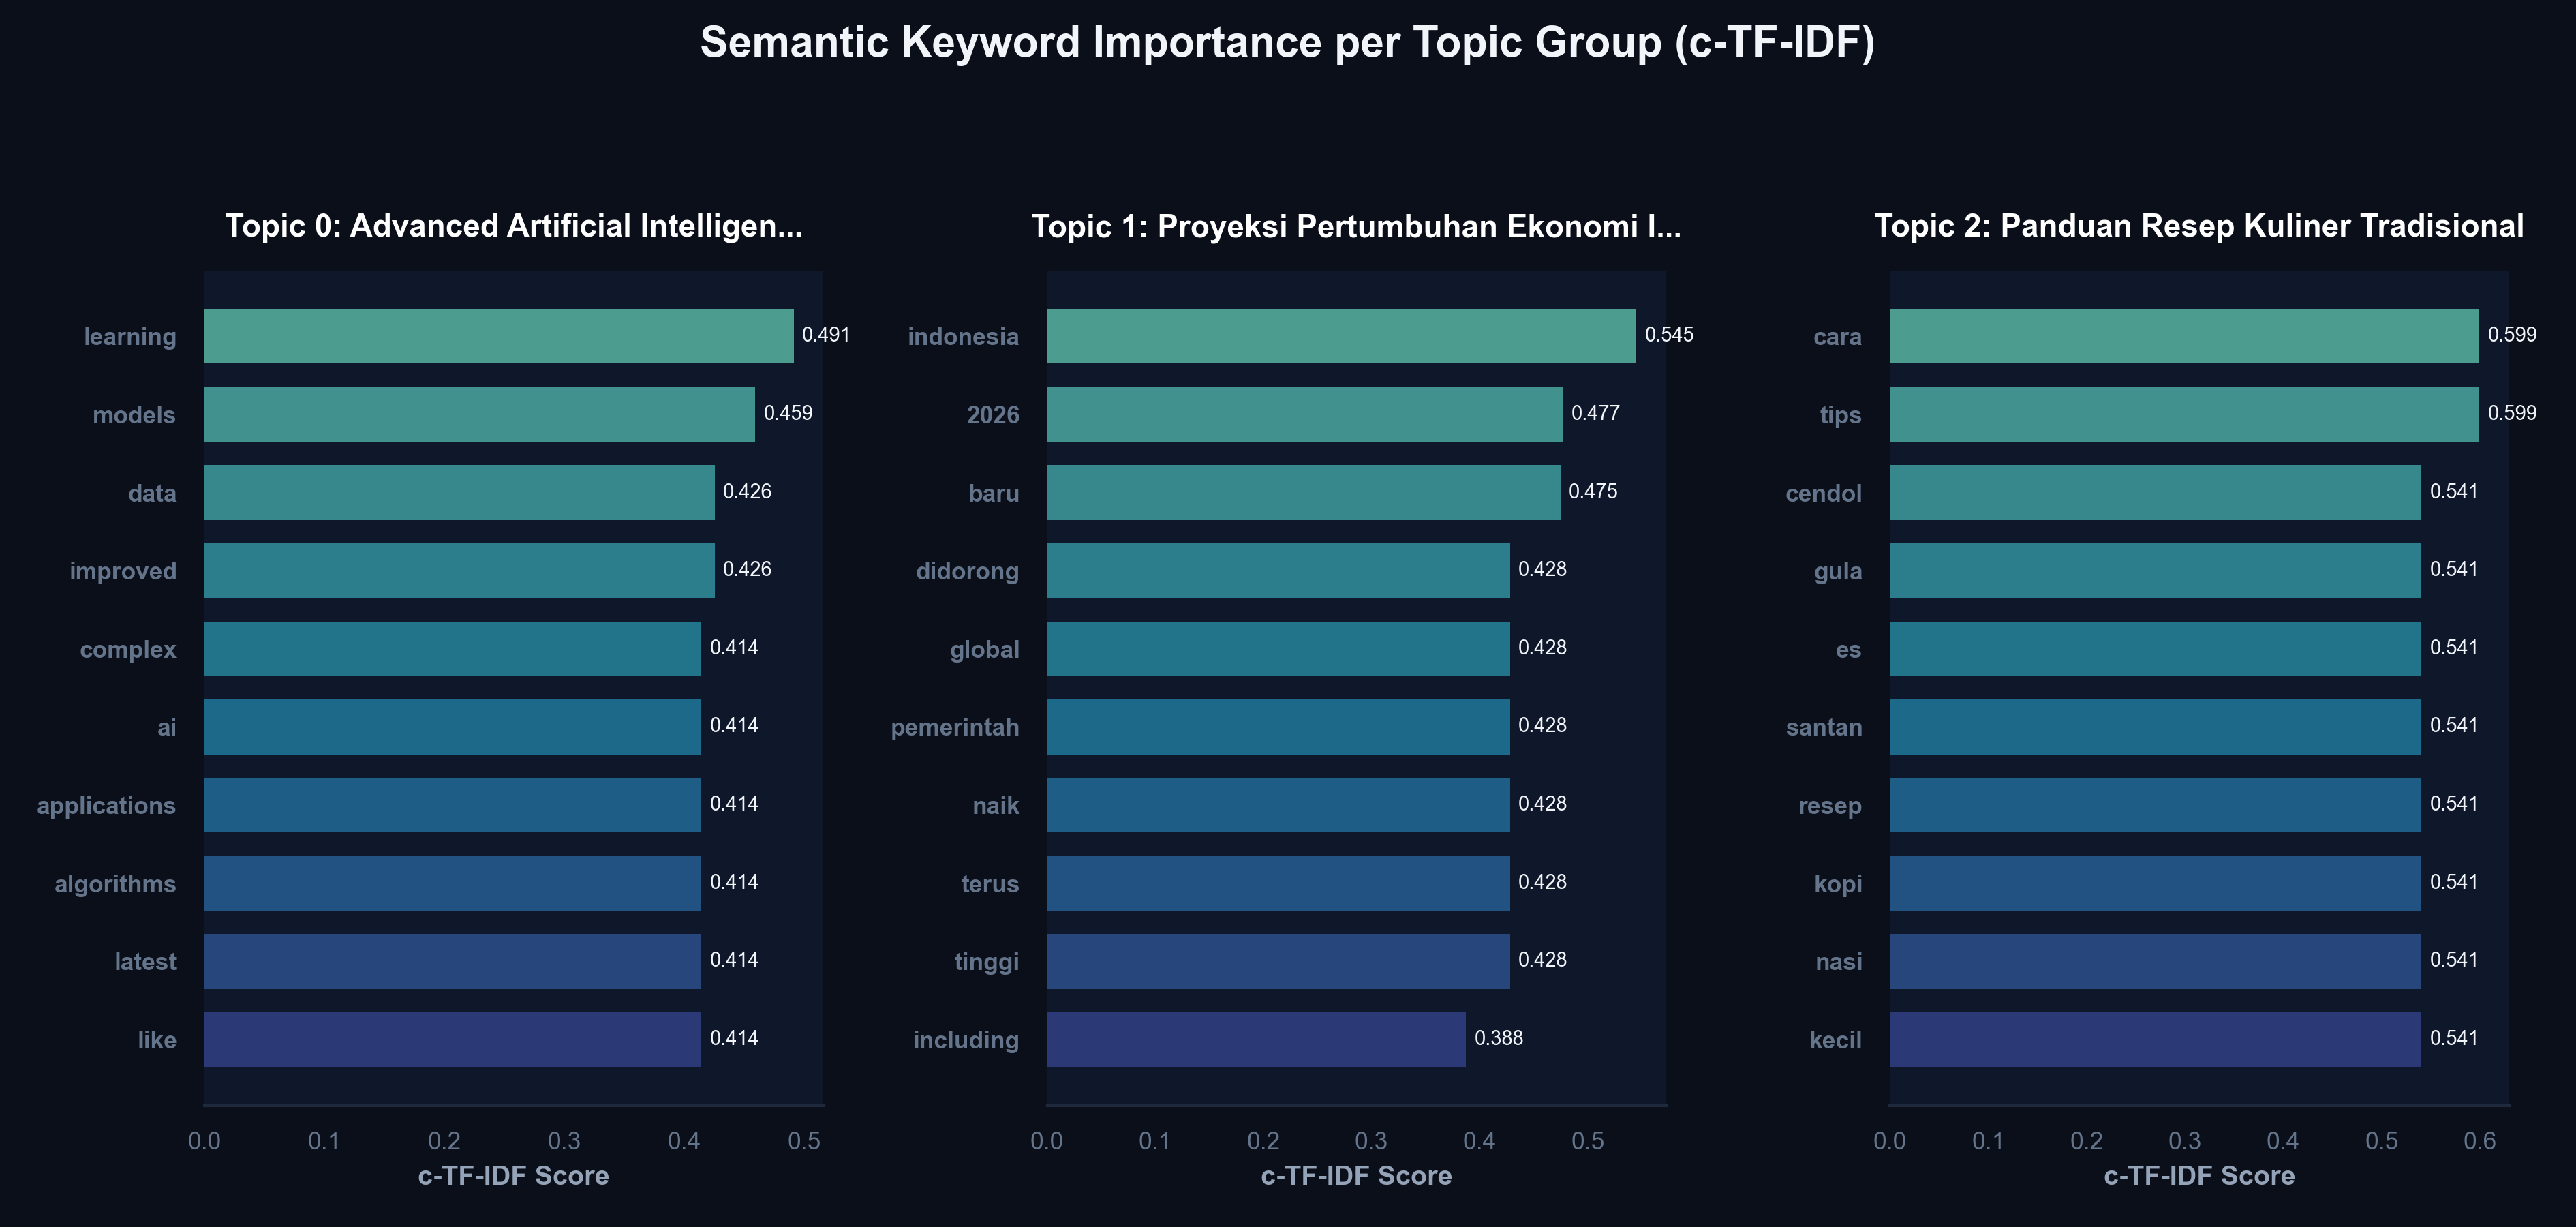
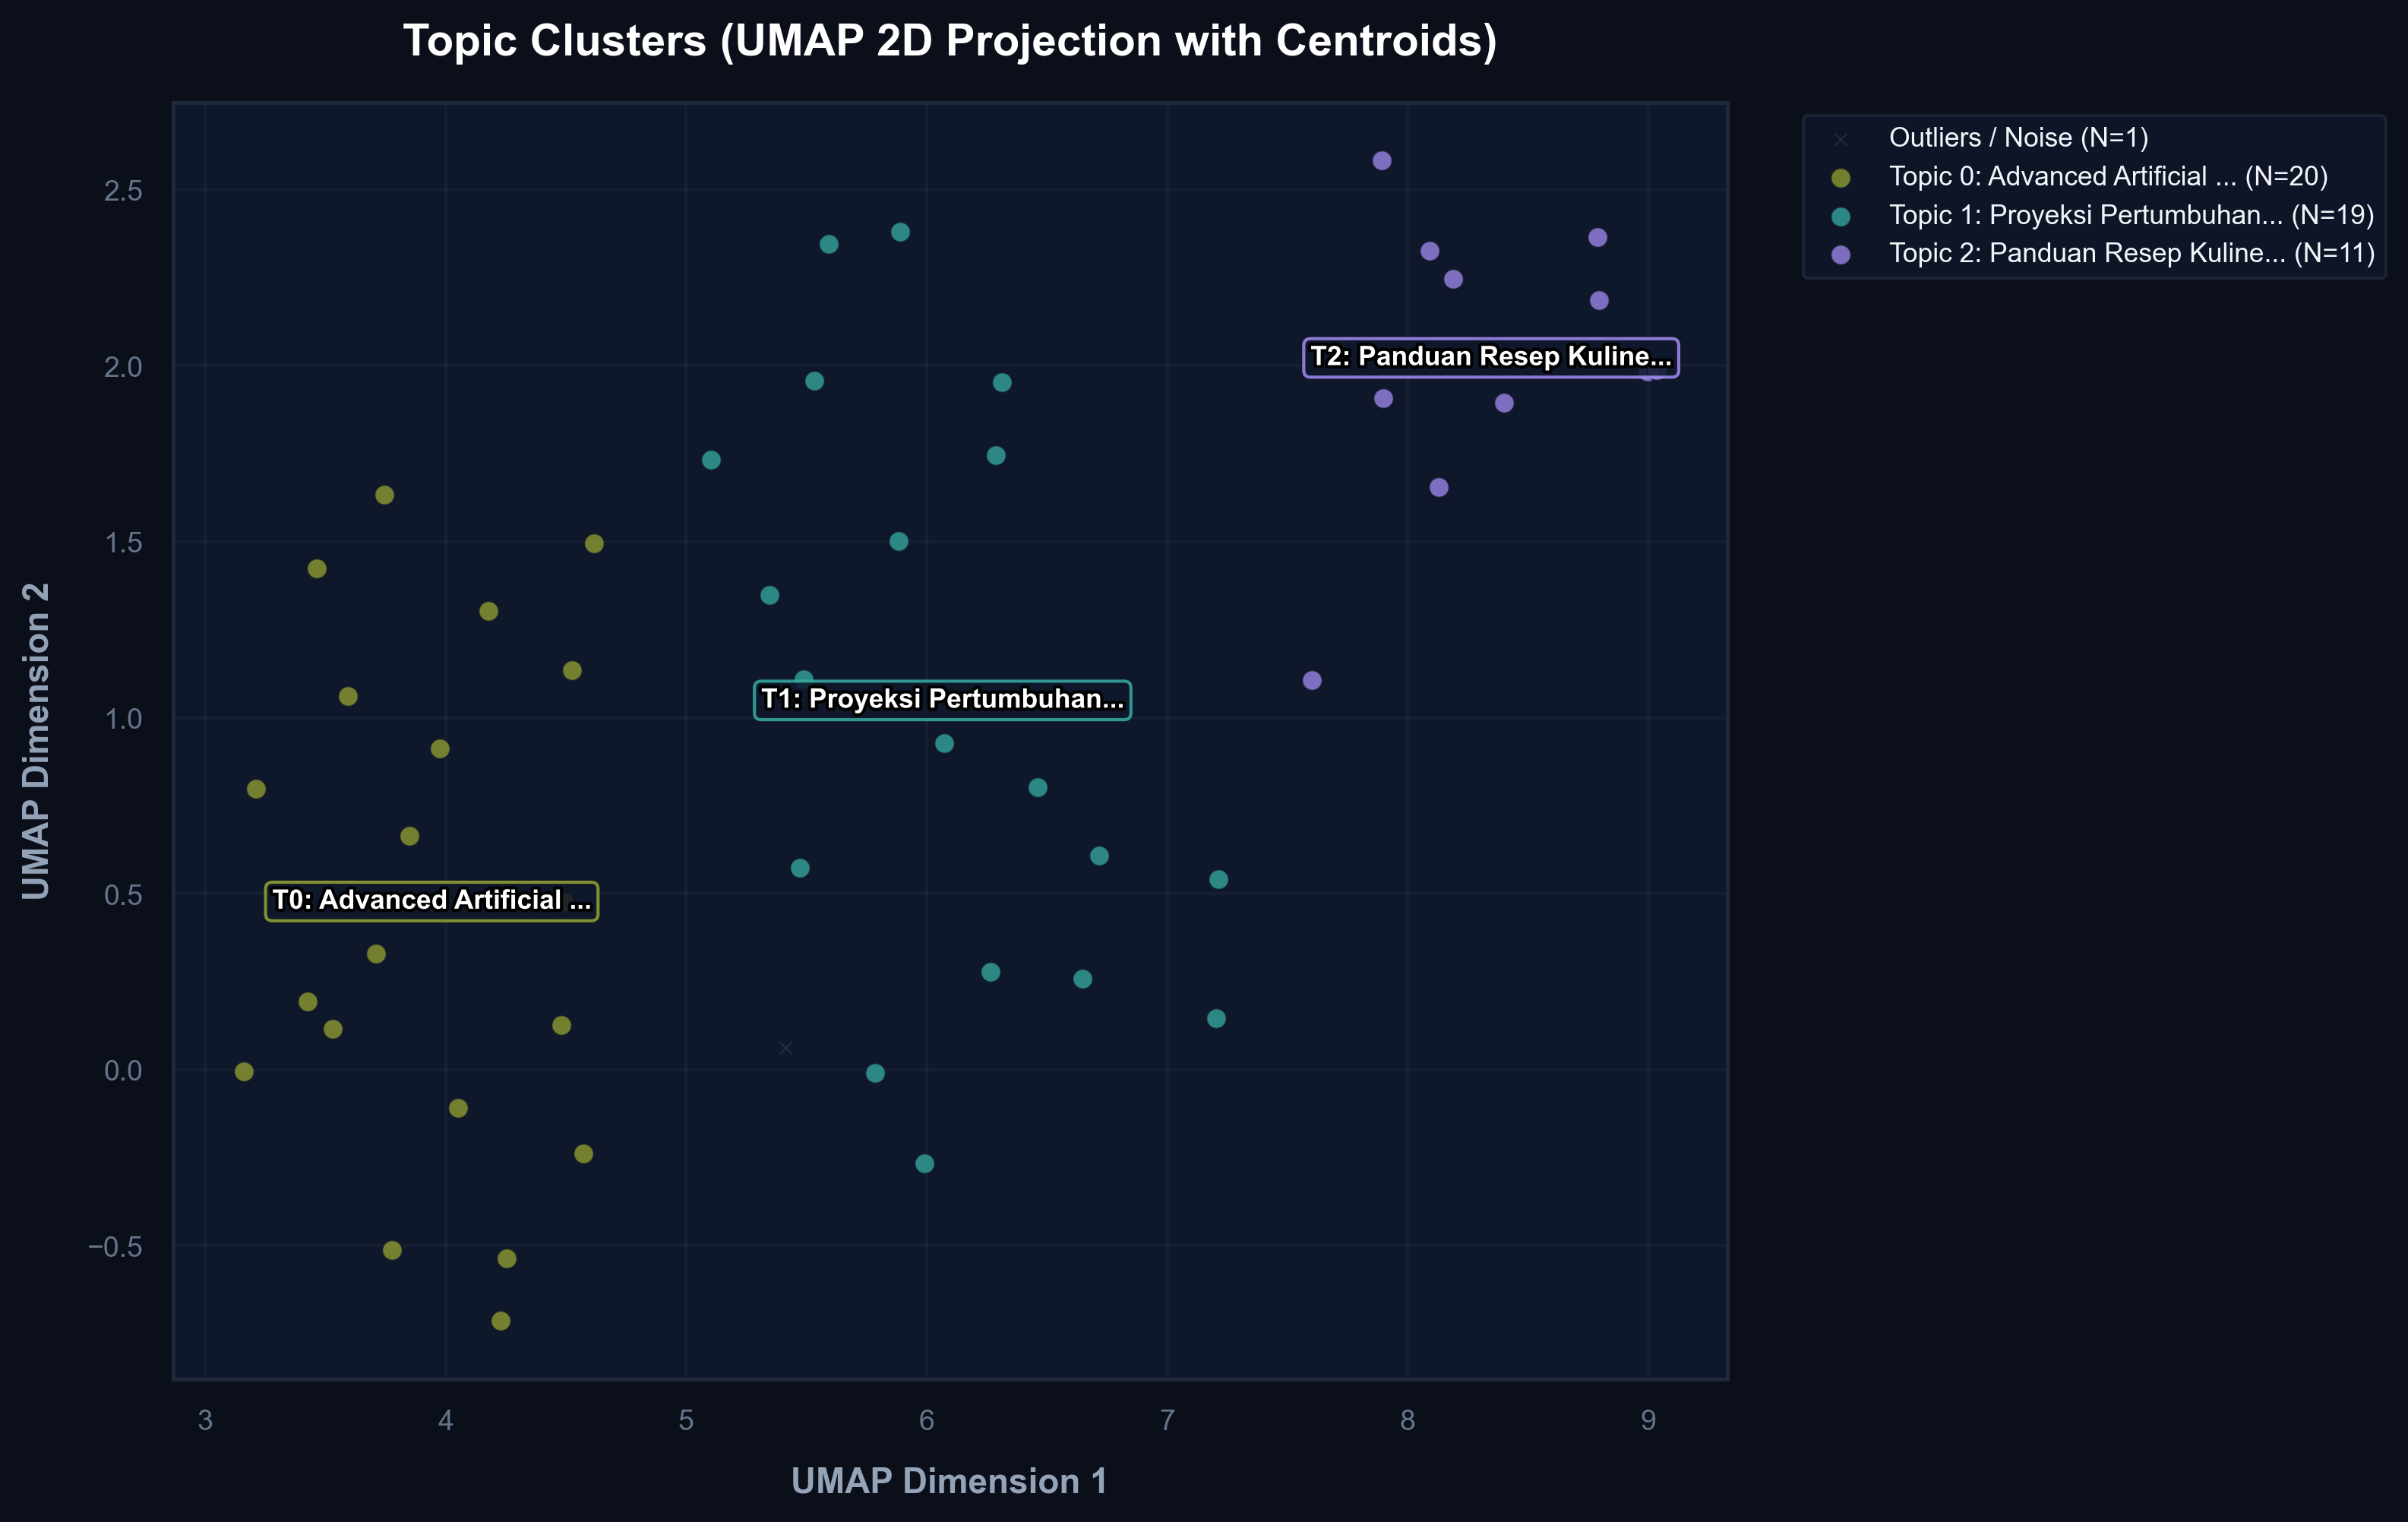

In [2]:
# ══════════════════════════════════════════════════════════════════════
#  Execute — Universal NLP Intelligence Pipeline
# ══════════════════════════════════════════════════════════════════════

from ml_engine import AutoMLFactory

factory = AutoMLFactory(AUTOML_CONFIG)
factory.execute_pipeline()

---
## 📤 Step 3: Batch Inference on Unseen Data
Run predictions on new, unseen text data. The engine automatically applies the same 15-step text cleaning pipeline and uses the trained model (or zero-shot pipeline) to generate predictions.

**Output varies by mode:**
- **Supervised**: Adds a `predictions` column with predicted labels/values.
- **Zero-Shot**: Adds `nlp_predicted_label` and `nlp_confidence` columns.
- **Unsupervised**: Adds a `topic_id` column with assigned topic IDs.

In [3]:
# ══════════════════════════════════════════════════════════════════════
#  Batch Inference & Export
# ══════════════════════════════════════════════════════════════════════

# factory.predict_and_export()